In [2]:
!python -V

Python 3.13.9


In [3]:
import pandas as pd
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, root_mean_squared_error

In [4]:
df_jan = pd.read_parquet('https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet')
df_feb = pd.read_parquet('https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-02.parquet')

In [5]:
# Q1. Number of columns in the January 2023 data
df_jan.shape[1] 

19

In [6]:
df_jan.tpep_pickup_datetime = pd.to_datetime(df_jan.tpep_pickup_datetime)
df_jan.tpep_dropoff_datetime = pd.to_datetime(df_jan.tpep_dropoff_datetime)
df_feb.tpep_pickup_datetime = pd.to_datetime(df_feb.tpep_pickup_datetime)
df_feb.tpep_dropoff_datetime = pd.to_datetime(df_feb.tpep_dropoff_datetime)

In [7]:
df_jan['duration'] = df_jan.tpep_dropoff_datetime - df_jan.tpep_pickup_datetime # duration
df_jan.duration = df_jan.duration.apply(lambda td_jan: td_jan.total_seconds() / 60)
df_feb['duration'] = df_feb.tpep_dropoff_datetime - df_feb.tpep_pickup_datetime # duration
df_feb.duration = df_feb.duration.apply(lambda td_feb: td_feb.total_seconds() / 60)

/tmp/ipykernel_17111/3843920651.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_jan.duration)
/tmp/ipykernel_17111/3843920651.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_feb.duration)


<Axes: xlabel='duration', ylabel='Density'>

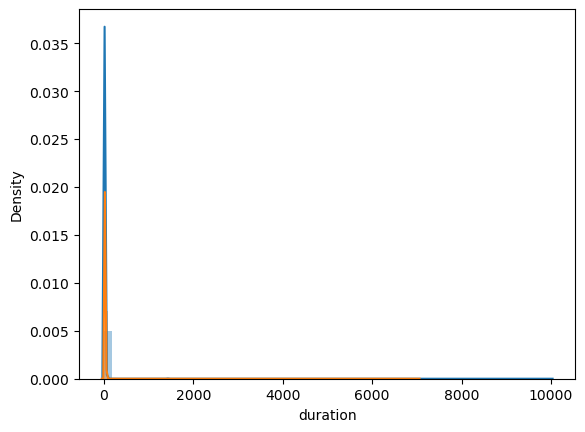

In [8]:
td_jan = df_jan.duration.iloc[0]
td_feb = df_feb.duration.iloc[0]
sns.distplot(df_jan.duration)
sns.distplot(df_feb.duration)

In [10]:
# Q2: the standard deviation of the trips duration in Jan is 42.59
df_jan.duration.describe() 
#df_jan.duration.describe(percentiles=[0.95, 0.98, 0.99]) 

count    3.066766e+06
mean     1.566900e+01
std      4.259435e+01
min     -2.920000e+01
25%      7.116667e+00
50%      1.151667e+01
75%      1.830000e+01
max      1.002918e+04
Name: duration, dtype: float64

In [11]:
df_jan = df_jan[(df_jan.duration >= 1) & (df_jan.duration <= 60)]
df_feb = df_feb[(df_feb.duration >= 1) & (df_feb.duration <= 60)]
categorical = ['PULocationID', 'DOLocationID']
numerical = ['trip_distance']
# re-cast the ids to strings
df_jan[categorical] = df_jan[categorical].astype(str)
df_feb[categorical] = df_feb[categorical].astype(str)

In [12]:
# Turn dataframe into a list of dictionaries
train_dicts = df_jan[categorical + numerical].to_dict(orient='records')
valid_dicts = df_feb[categorical + numerical].to_dict(orient='records')

# Fit a dictionary vectorizer
dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)
X_val = dv.fit_transform(valid_dicts)

X_train

: 